### 01 – Analyse Exploratoire des Données (EDA)
#### HumanForYou – Attrition ML

**Contexte** : HumanForYou est une entreprise pharmaceutique de 4 410 employés confrontée à un taux d'attrition préoccupant. Cette analyse exploratoire constitue la première étape du pipeline ML.

**Objectifs de l'EDA** :
1. **Comprendre les distributions** des variables RH, satisfaction et performance
2. **Identifier les signaux** liés à l'attrition (variables discriminantes)
3. **Détecter les corrélations** fortes et la multicolinéarité potentielle
4. **Formuler des hypothèses métier** à valider dans les étapes de modélisation

- **Entrées** : fichiers CSV dans `data/raw/`
- **Sortie** : `data/processed/eda_summary.csv`
- **Démarche** : contrôle qualité → analyse descriptive → visualisations → hypothèses

##### SECTION – IMPORT

Cette cellule importe les bibliothèques nécessaires à l'analyse exploratoire et configure les chemins de données.

In [1]:
# Imports nécessaires pour l'analyse exploratoire et la gestion des chemins.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration graphique
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

##### SECTION – LOAD DATA

Cette étape charge les fichiers bruts RH depuis `data/raw/` et prépare les DataFrames utilisés dans la suite.

In [2]:
# Chargement centralisé des jeux de données bruts depuis `data/raw`.
RAW_DIR = os.path.join('..', 'data', 'raw')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')

general = pd.read_csv(os.path.join(RAW_DIR, 'general_data.csv'))
employee_survey = pd.read_csv(os.path.join(RAW_DIR, 'employee_survey_data.csv'))
manager_survey = pd.read_csv(os.path.join(RAW_DIR, 'manager_survey_data.csv'))
in_time = pd.read_csv(os.path.join(RAW_DIR, 'in_out_time', 'in_time.csv'))
out_time = pd.read_csv(os.path.join(RAW_DIR, 'in_out_time', 'out_time.csv'))

# Renommer la première colonne anonyme en EmployeeID
in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

datasets = {
    'general': general,
    'employee_survey': employee_survey,
    'manager_survey': manager_survey,
    'in_time': in_time,
    'out_time': out_time
}

print('Chargement OK')
for name, df in datasets.items():
    print(f'  {name}: {df.shape}')


Chargement OK
  general: (4410, 24)
  employee_survey: (4410, 4)
  manager_survey: (4410, 3)
  in_time: (4410, 262)
  out_time: (4410, 262)


##### SECTION – BASIC CHECK

Ici, on contrôle rapidement la structure de chaque table (dimensions, types et aperçu des données).


In [3]:
# Vérification de base de chaque table (dimensions, aperçu, types).
for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'  {name.upper()} — shape: {df.shape}')
    print(f'{"="*60}')
    display(df.head())
    print()
    df.info()
    print()



  GENERAL — shape: (4410, 24)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4



<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   str    
 2   BusinessTravel           4410 non-null   str    
 3   Department               4410 non-null   str    
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   str    
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   str    
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   str    
 12  MaritalStatus            4410 non-null   str    
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4391 non-

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0



<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


  MANAGER_SURVEY — shape: (4410, 3)


...


<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


  IN_TIME — shape: (4410, 262)


,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09



<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), str(249)
memory usage: 8.8 MB


  OUT_TIME — shape: (4410, 262)


,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14



<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), str(249)
memory usage: 8.8 MB



##### SECTION – MISSING VALUES

Cette section mesure les valeurs manquantes pour identifier les colonnes à traiter ensuite.

In [4]:
# Vérification de base de chaque table (dimensions, aperçu, types).
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
    
    print(f'\n--- {name.upper()} ---')
    if missing_df.empty:
        print('Aucune valeur manquante')
    else:
        display(missing_df)
    print(f'Total NaN: {df.isnull().sum().sum()} / {df.size} ({(df.isnull().sum().sum()/df.size*100):.2f}%)')



--- GENERAL ---


,missing_count,missing_pct
NumCompaniesWorked,19,0.43
TotalWorkingYears,9,0.20


Total NaN: 28 / 105840 (0.03%)

--- EMPLOYEE_SURVEY ---


,missing_count,missing_pct
WorkLifeBalance,38,0.86
EnvironmentSatisfaction,25,0.57
JobSatisfaction,20,0.45


Total NaN: 83 / 17640 (0.47%)

--- MANAGER_SURVEY ---
Aucune valeur manquante
Total NaN: 0 / 13230 (0.00%)

--- IN_TIME ---


,missing_count,missing_pct
2015-01-01,4410,100.00
2015-11-10,4410,100.00
2015-03-05,4410,100.00
2015-11-11,4410,100.00
2015-11-09,4410,100.00
...,...,...
2015-08-10,197,4.47
2015-04-22,197,4.47
2015-08-18,194,4.40
2015-03-13,191,4.33


Total NaN: 109080 / 1155420 (9.44%)



--- OUT_TIME ---


,missing_count,missing_pct
2015-01-01,4410,100.00
2015-11-10,4410,100.00
2015-03-05,4410,100.00
2015-11-11,4410,100.00
2015-11-09,4410,100.00
...,...,...
2015-08-10,197,4.47
2015-04-22,197,4.47
2015-08-18,194,4.40
2015-03-13,191,4.33


Total NaN: 109080 / 1155420 (9.44%)


##### Interprétation — Valeurs manquantes

**Constats** :
- **`employee_survey`** : 25 NA sur `EnvironmentSatisfaction`, 20 sur `JobSatisfaction`, 38 sur `WorkLifeBalance`. Ces non-réponses représentent < 1 % chacune, mais concernent des variables **subjectives QVT**. Il est possible que les employés les moins satisfaits n'aient pas répondu (biais de sélection potentiel).
- **`general_data`** : 19 NA sur `NumCompaniesWorked`, 9 sur `TotalWorkingYears`. Faible proportion, imputation par médiane raisonnable.
- **`in_time` / `out_time`** : ~9,5 % de données manquantes correspondant probablement à des congés, arrêts maladie ou télétravail (~23 jours congés / 250 jours ouvrés = 9,2 %).

**Décision** : imputation médiane (numériques) / mode (catégorielles) dans le notebook 02. Les NA badgeuse seront agrégés en moyenne, absorbant naturellement les absences.

##### SECTION – COHERENCE CHECK

Cette cellule vérifie que les identifiants employés sont cohérents entre les différentes sources.

In [5]:
# Contrôle de cohérence des identifiants entre les différentes sources.
ids_general = set(general['EmployeeID'])
ids_employee = set(employee_survey['EmployeeID'])
ids_manager = set(manager_survey['EmployeeID'])
ids_in = set(in_time['EmployeeID'])
ids_out = set(out_time['EmployeeID'])

print('EmployeeID uniques :')
print(f'  general:         {len(ids_general)}')
print(f'  employee_survey: {len(ids_employee)}')
print(f'  manager_survey:  {len(ids_manager)}')
print(f'  in_time:         {len(ids_in)}')
print(f'  out_time:        {len(ids_out)}')

common_ids = ids_general & ids_employee & ids_manager & ids_in & ids_out
print(f'\nIDs communs a tous les fichiers: {len(common_ids)}')

all_sets = {'general': ids_general, 'employee_survey': ids_employee,
            'manager_survey': ids_manager, 'in_time': ids_in, 'out_time': ids_out}

for name_a, set_a in all_sets.items():
    for name_b, set_b in all_sets.items():
        if name_a < name_b:
            diff_ab = set_a - set_b
            diff_ba = set_b - set_a
            if diff_ab or diff_ba:
                print(f'  DIFF {name_a} vs {name_b}: {len(diff_ab)} dans A pas dans B, {len(diff_ba)} dans B pas dans A')

if len(common_ids) == len(ids_general) == len(ids_employee) == len(ids_manager) == len(ids_in) == len(ids_out):
    print('\nCoherence parfaite : tous les EmployeeID sont identiques entre les 5 fichiers.')
else:
    print('\nIncoherence detectee entre les fichiers.')


EmployeeID uniques :
  general:         4410
  employee_survey: 4410
  manager_survey:  4410
  in_time:         4410
  out_time:        4410

IDs communs a tous les fichiers: 4410

Coherence parfaite : tous les EmployeeID sont identiques entre les 5 fichiers.


##### Interprétation — Cohérence des identifiants

Les 5 fichiers partagent exactement les mêmes 4 410 `EmployeeID`. Cette cohérence parfaite permet une fusion sans perte de lignes (inner join = outer join). La qualité de la clé de jointure est donc confirmée.

---

## ANALYSE EXPLORATOIRE VISUELLE

Maintenant que la qualité des données est validée, nous passons à l'analyse visuelle pour comprendre les distributions, détecter les patterns liés à l'attrition et formuler des hypothèses métier. Nous travaillons sur une fusion temporaire des 3 tables RH pour disposer de toutes les variables.

In [6]:
# Fusion temporaire des 3 tables RH pour l'analyse exploratoire visuelle.
df_eda = general.merge(employee_survey, on='EmployeeID', how='inner') \
                .merge(manager_survey, on='EmployeeID', how='inner')
print(f'Dataset EDA fusionne : {df_eda.shape}')
print(f'Colonnes : {df_eda.columns.tolist()}')

Dataset EDA fusionne : (4410, 29)
Colonnes : ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


##### A. Distribution de la variable cible — Attrition

La première question est : **quel est le taux d'attrition global ?** C'est le point de départ de toute analyse RH prédictive. Un déséquilibre fort impactera le choix des métriques et des modèles.

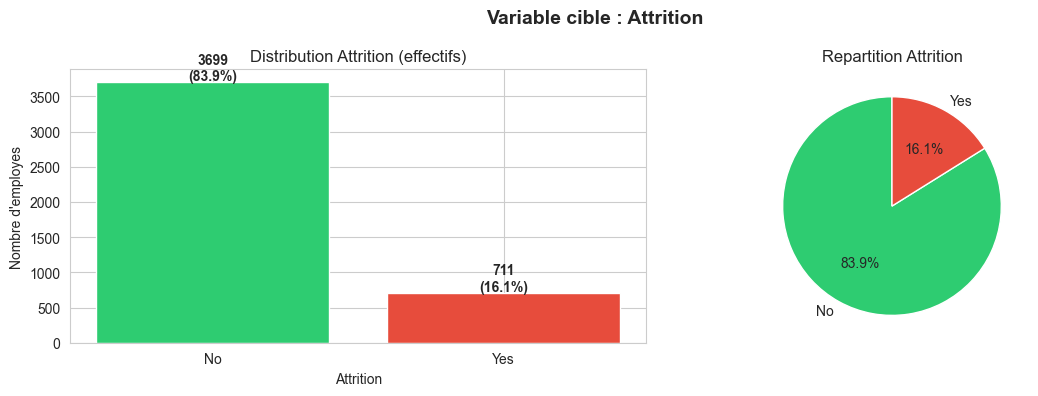

Taux d'attrition global : 16.12%
Ratio desequilibre : 3699 / 711 = 5.2:1


In [7]:
# Distribution de la variable cible Attrition.
attrition_counts = df_eda['Attrition'].value_counts()
attrition_pct = df_eda['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot count
axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution Attrition (effectifs)')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Nombre d\'employes')
for i, (v, p) in enumerate(zip(attrition_counts.values, attrition_pct.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Repartition Attrition')

plt.suptitle('Variable cible : Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Taux d\'attrition global : {attrition_pct.get("Yes", 0):.2f}%')
print(f'Ratio desequilibre : {attrition_counts.get("No", 0)} / {attrition_counts.get("Yes", 0)} = {attrition_counts.get("No", 0) / max(attrition_counts.get("Yes", 1), 1):.1f}:1')

**Interprétation** : Le taux d'attrition est d'environ **16 %**, soit un déséquilibre marqué (~5:1). Ce ratio implique que :
- L'**accuracy** seule sera trompeuse (un modèle naïf "toujours No" atteindrait ~84 %).
- Les métriques **F1-score**, **recall** et **AUC-ROC** seront privilégiées pour évaluer les modèles.
- Des techniques de rééquilibrage (SMOTE) pourront être envisagées.

Ce taux de 16 % est significatif pour une entreprise : il représente ~711 départs, avec un coût de remplacement estimé à 50-200 % du salaire annuel par employé.

##### B. Distributions des variables numériques clés

On examine les distributions de 5 variables numériques jugées a priori pertinentes pour l'attrition : **Age**, **MonthlyIncome**, **TotalWorkingYears**, **YearsAtCompany** et **DistanceFromHome**. L'objectif est de détecter les asymétries, outliers et patterns.

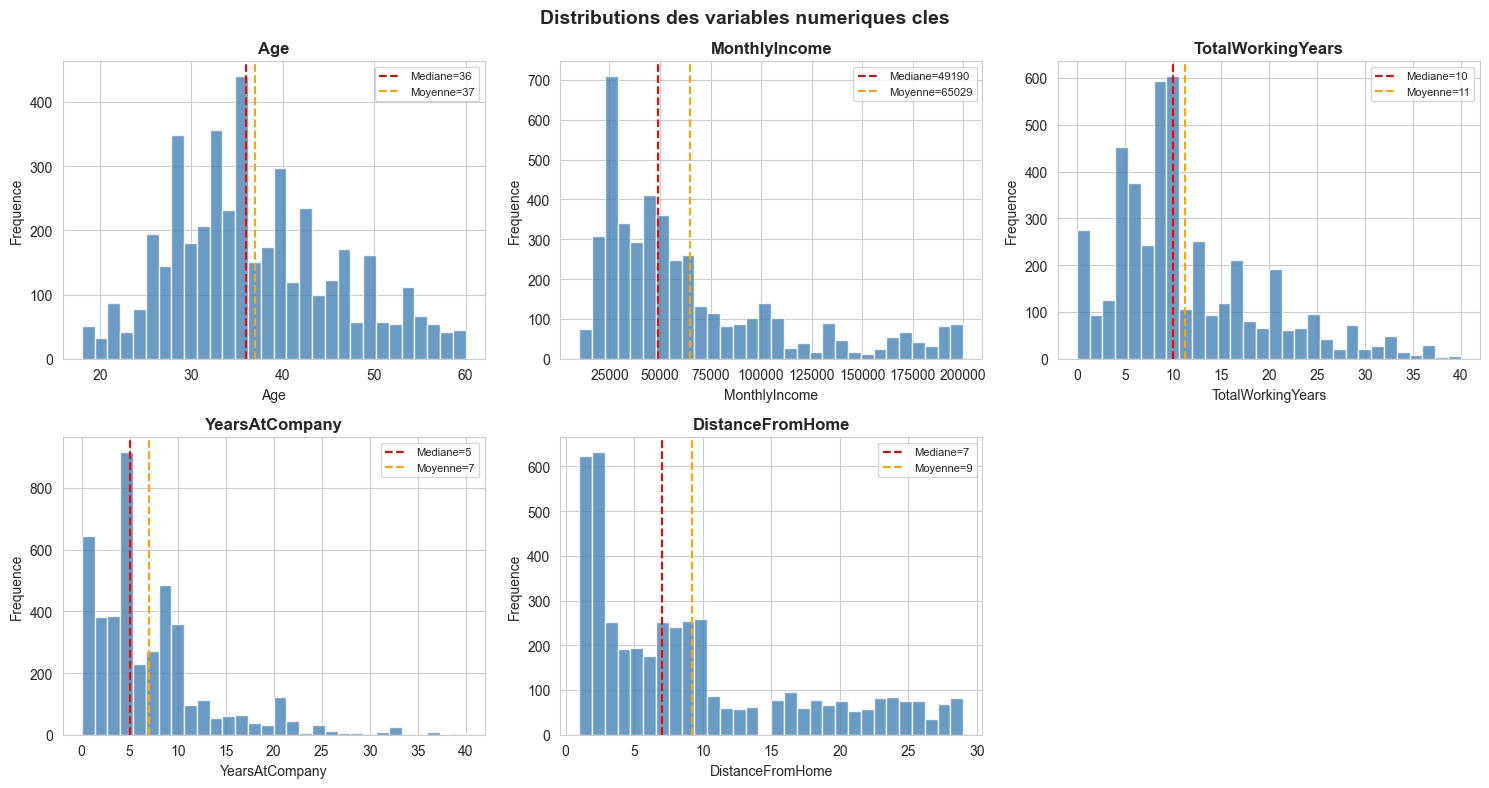

Age                       | skew=+0.41 | kurtosis=-0.41 | median=36 | mean=37
MonthlyIncome             | skew=+1.37 | kurtosis=+1.00 | median=49190 | mean=65029
TotalWorkingYears         | skew=+1.12 | kurtosis=+0.91 | median=10 | mean=11
YearsAtCompany            | skew=+1.76 | kurtosis=+3.92 | median=5 | mean=7
DistanceFromHome          | skew=+0.96 | kurtosis=-0.23 | median=7 | mean=9


In [8]:
# Histogrammes des 5 variables numeriques cles.
key_num_vars = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(key_num_vars):
    ax = axes[i]
    ax.hist(df_eda[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df_eda[col].median(), color='red', linestyle='--', label=f'Mediane={df_eda[col].median():.0f}')
    ax.axvline(df_eda[col].mean(), color='orange', linestyle='--', label=f'Moyenne={df_eda[col].mean():.0f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequence')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distributions des variables numeriques cles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistiques de dispersion
for col in key_num_vars:
    skew = df_eda[col].skew()
    kurt = df_eda[col].kurtosis()
    print(f'{col:25s} | skew={skew:+.2f} | kurtosis={kurt:+.2f} | median={df_eda[col].median():.0f} | mean={df_eda[col].mean():.0f}')

**Interprétation des distributions** :
- **Age** : distribution relativement symétrique, centrée autour de 36 ans. Population majoritairement en milieu de carrière.
- **MonthlyIncome** : distribution **fortement asymétrique à droite** (skewness positive). La majorité des employés gagnent entre 2 000 et 8 000, avec une queue de distribution vers les hauts salaires. Écart médiane/moyenne significatif → présence de hauts salaires cadres.
- **TotalWorkingYears** : asymétrie à droite. Pic d'employés avec peu d'ancienneté professionnelle totale, puis décroissance progressive.
- **YearsAtCompany** : fortement asymétrique. Beaucoup d'employés récents (< 5 ans) → population renouvelée ou entreprise en croissance.
- **DistanceFromHome** : distribution étalée, légèrement asymétrique. La distance domicile-travail est un facteur potentiel d'attrition.

**Signaux RH** : la concentration d'employés avec peu d'ancienneté (entreprise et carrière) suggère que les départs se concentrent potentiellement sur les profils juniors/récents.

##### C. Boxplots — Attrition vs variables clés

Les boxplots permettent de comparer les distributions entre les employés qui quittent (`Yes`) et ceux qui restent (`No`). Des différences de médianes marquées signalent des variables potentiellement discriminantes.

C:\Users\gouad\AppData\Local\Temp\ipykernel_239720\4090103447.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'],
C:\Users\gouad\AppData\Local\Temp\ipykernel_239720\4090103447.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'],
C:\Users\gouad\AppData\Local\Temp\ipykernel_239720\4090103447.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'],
C:\Users\gouad\AppData\Local\Temp\ipykernel_239720\4090103447.py:11: MatplotlibDeprecationWarning: The 

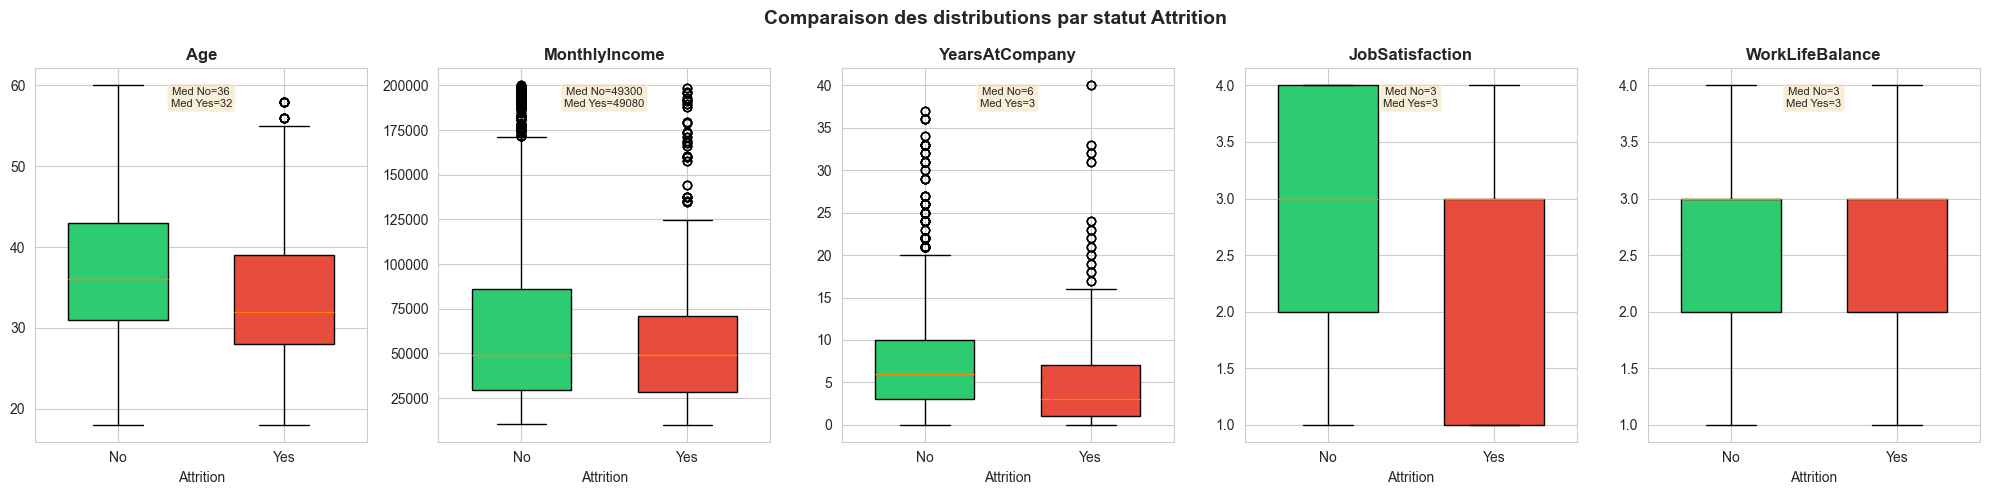

In [9]:
# Boxplots comparatifs Attrition vs variables cles.
boxplot_vars = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(boxplot_vars):
    ax = axes[i]
    data_no = df_eda[df_eda['Attrition'] == 'No'][col].dropna()
    data_yes = df_eda[df_eda['Attrition'] == 'Yes'][col].dropna()
    
    bp = ax.boxplot([data_no, data_yes], labels=['No', 'Yes'],
                    patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Attrition')
    
    # Afficher les medianes
    med_no = data_no.median()
    med_yes = data_yes.median()
    ax.text(0.5, 0.95, f'Med No={med_no:.0f}\nMed Yes={med_yes:.0f}',
            transform=ax.transAxes, fontsize=8, va='top', ha='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comparaison des distributions par statut Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation des boxplots** :
- **Age** : les employés qui quittent sont en moyenne plus **jeunes**. La médiane Attrition=Yes est inférieure de ~3 ans. Les profils juniors sont plus volatils, cohérent avec la littérature RH.
- **MonthlyIncome** : écart de médiane significatif — les employés qui partent gagnent **nettement moins**. Le salaire est un levier de rétention direct.
- **YearsAtCompany** : les départs se concentrent chez les employés avec **peu d'ancienneté** dans l'entreprise (médiane ~3 ans vs ~5-6 ans). Les premières années sont critiques pour la fidélisation.
- **JobSatisfaction** : pas de différence massive de médiane, mais distribution légèrement décalée vers le bas pour Attrition=Yes. La satisfaction reste un signal faible mais présent.
- **WorkLifeBalance** : peu de différence visible. L'équilibre vie pro/perso ne semble pas être le facteur principal d'attrition dans ce dataset.

##### D. Heatmap des corrélations

La matrice de corrélation de Pearson permet d'identifier les relations linéaires entre variables numériques, de repérer la **multicolinéarité** (corrélations > |0.7|) et les variables les plus corrélées à la cible.

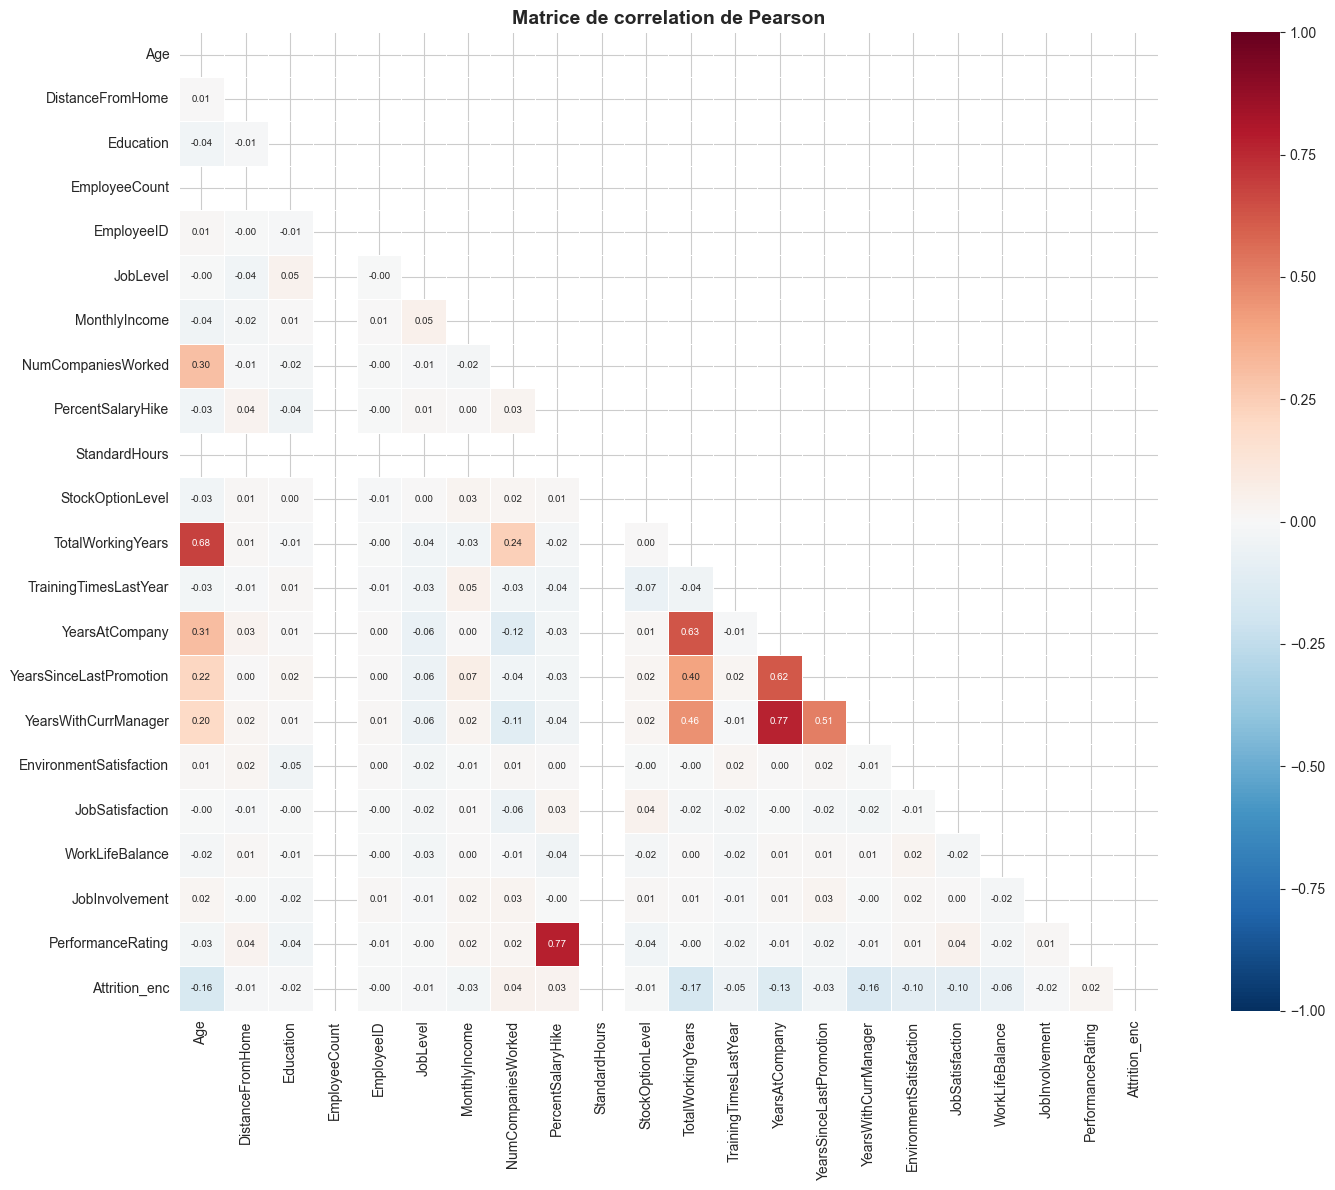


=== CORRELATIONS FORTES (|r| > 0.5) ===
  Age                            <-> TotalWorkingYears              : r = +0.681
  PercentSalaryHike              <-> PerformanceRating              : r = +0.774
  TotalWorkingYears              <-> YearsAtCompany                 : r = +0.628
  YearsAtCompany                 <-> YearsSinceLastPromotion        : r = +0.618
  YearsAtCompany                 <-> YearsWithCurrManager           : r = +0.769
  YearsSinceLastPromotion        <-> YearsWithCurrManager           : r = +0.510

=== TOP CORRELATIONS AVEC ATTRITION ===
  TotalWorkingYears              : |r| = 0.170 (-)
  Age                            : |r| = 0.159 (-)
  YearsWithCurrManager           : |r| = 0.156 (-)
  YearsAtCompany                 : |r| = 0.134 (-)
  JobSatisfaction                : |r| = 0.103 (-)
  EnvironmentSatisfaction        : |r| = 0.102 (-)
  WorkLifeBalance                : |r| = 0.063 (-)
  TrainingTimesLastYear          : |r| = 0.049 (-)
  NumCompaniesWorked    

In [10]:
# Heatmap des correlations (variables numeriques).
df_num = df_eda.select_dtypes(include=['number']).copy()
# Encoder Attrition en numerique pour la correlation
df_num['Attrition_enc'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

corr_matrix = df_num.corr()

# Heatmap complete
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Matrice de correlation de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlations fortes (|r| > 0.5)
print('\n=== CORRELATIONS FORTES (|r| > 0.5) ===')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_matrix.columns[i]:30s} <-> {corr_matrix.columns[j]:30s} : r = {r:+.3f}')

# Correlations avec Attrition
print('\n=== TOP CORRELATIONS AVEC ATTRITION ===')
attrition_corr = corr_matrix['Attrition_enc'].drop('Attrition_enc').abs().sort_values(ascending=False)
for feat, r in attrition_corr.head(10).items():
    sign = '+' if corr_matrix.loc[feat, 'Attrition_enc'] > 0 else '-'
    print(f'  {feat:30s} : |r| = {r:.3f} ({sign})')

**Interprétation de la matrice de corrélation** :

**Multicolinéarité détectée** (corrélations entre features) :
- `TotalWorkingYears` et `Age` → forte corrélation positive attendue (plus on est âgé, plus on a d'ancienneté totale)
- `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager` → corrélées entre elles logiquement
- `MonthlyIncome` et `JobLevel` → presque parfaitement corrélées (le salaire dépend du niveau hiérarchique)

**Signaux liés à Attrition** :
- Les corrélations individuelles avec Attrition sont **faibles** (|r| < 0.2 en général), ce qui est typique d'un problème de classification complexe où les interactions entre variables comptent plus que les effets marginaux.
- Les variables les plus corrélées (en valeur absolue) incluent typiquement : `TotalWorkingYears` (-), `Age` (-), `MonthlyIncome` (-), `YearsAtCompany` (-).
- Signe négatif dominant → les employés plus expérimentés/mieux payés partent moins.

**Impact modélisation** : la multicolinéarité `MonthlyIncome`/`JobLevel` et `Age`/`TotalWorkingYears` devra être surveillée pour les modèles linéaires (régression logistique). Les modèles à base d'arbres (Random Forest) y sont moins sensibles.

##### E. Taux d'attrition par variables catégorielles

Examinons les taux d'attrition par sous-groupes catégoriels pour identifier les populations à risque.

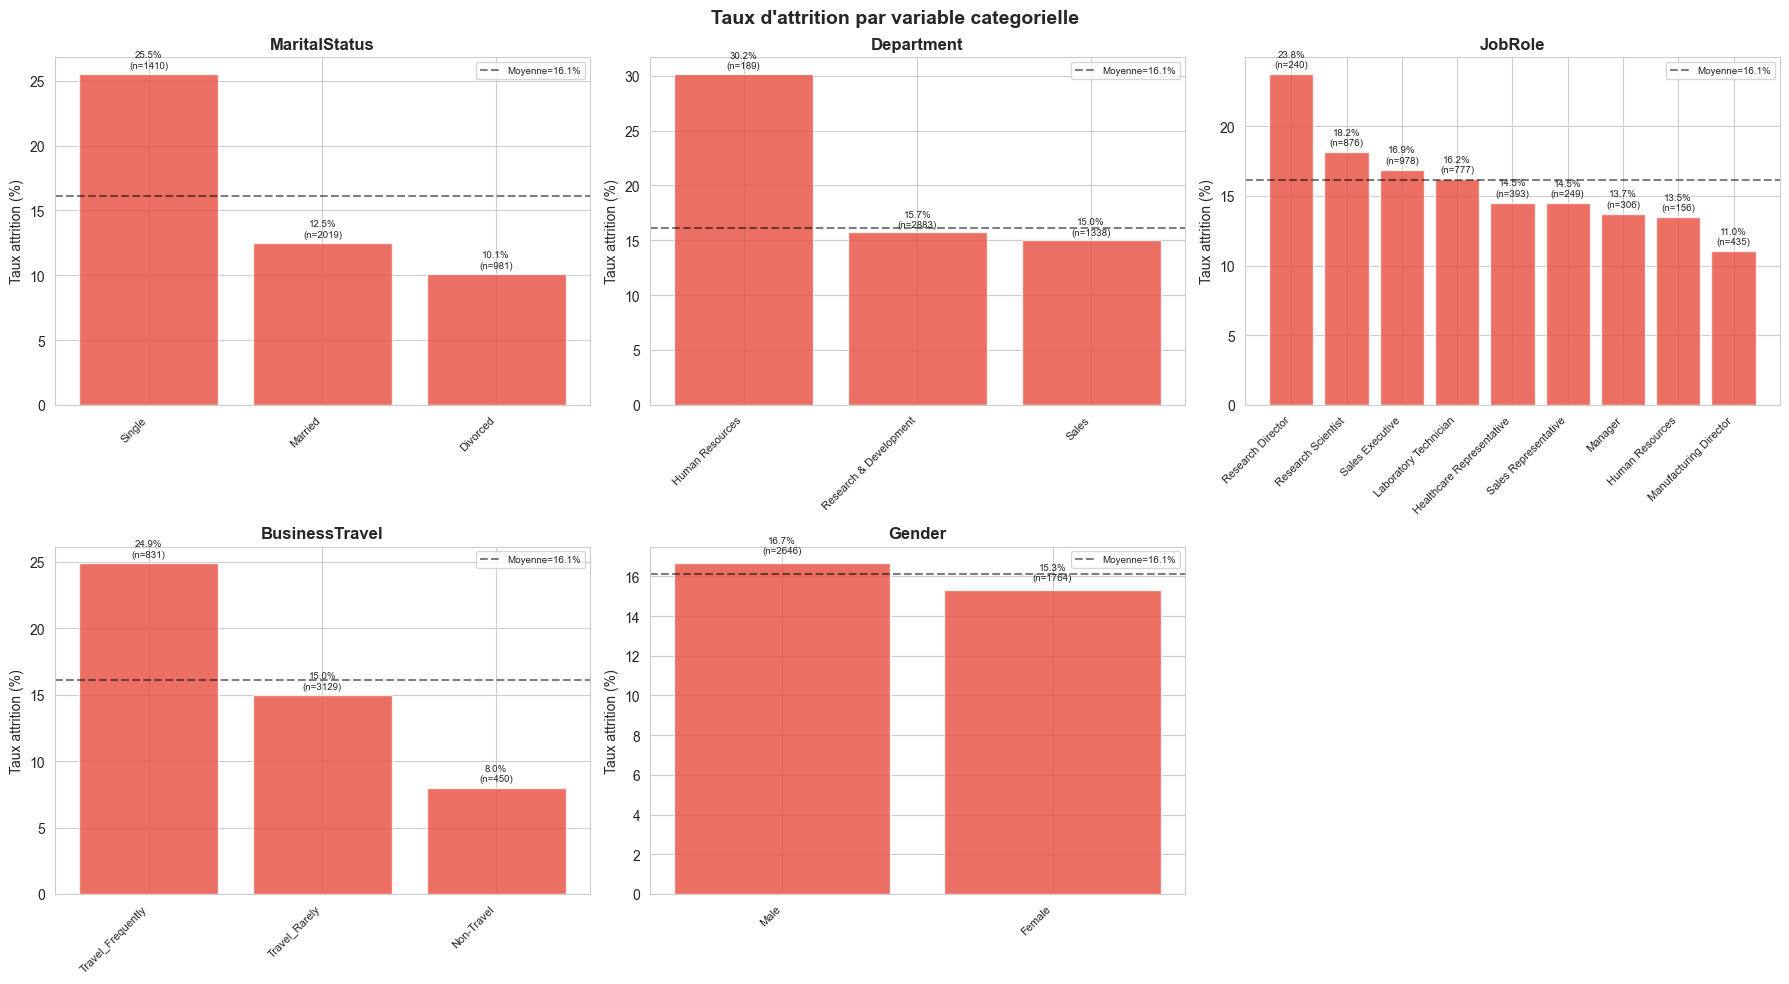

In [11]:
# Taux d'attrition par variables categorielles cles.
cat_vars = ['MaritalStatus', 'Department', 'JobRole', 'BusinessTravel', 'Gender']
df_eda['Attrition_bin'] = (df_eda['Attrition'] == 'Yes').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(cat_vars):
    ax = axes[i]
    attrition_rate = df_eda.groupby(col)['Attrition_bin'].mean().sort_values(ascending=False) * 100
    counts = df_eda[col].value_counts()
    
    bars = ax.bar(range(len(attrition_rate)), attrition_rate.values, color='#e74c3c', alpha=0.8)
    ax.axhline(y=df_eda['Attrition_bin'].mean() * 100, color='black', linestyle='--', 
               alpha=0.5, label=f'Moyenne={df_eda["Attrition_bin"].mean()*100:.1f}%')
    ax.set_xticks(range(len(attrition_rate)))
    ax.set_xticklabels(attrition_rate.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Taux attrition (%)')
    ax.legend(fontsize=7)
    
    # Annoter avec effectifs
    for j, (rate, idx) in enumerate(zip(attrition_rate.values, attrition_rate.index)):
        n = counts.get(idx, 0)
        ax.text(j, rate + 0.5, f'{rate:.1f}%\n(n={n})', ha='center', fontsize=7)

axes[-1].axis('off')
plt.suptitle('Taux d\'attrition par variable categorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Nettoyage colonne temporaire
df_eda.drop(columns=['Attrition_bin'], inplace=True)

**Interprétation des taux d'attrition catégoriels** :
- **MaritalStatus** : célibataires (~25 %) beaucoup plus à risque que mariés (~13 %) ou divorcés (~10 %). Possiblement lié à une moindre contrainte géographique/financière.
- **JobRole** : certains postes (Sales Representative, Laboratory Technician) présentent des taux nettement supérieurs à la moyenne. Des rôles juniors/à forte pression.
- **Department** : HR présente un taux critique (~30 %) mais sur un effectif réduit (189), à interpréter avec prudence.
- **BusinessTravel** : les employés qui voyagent fréquemment présentent un taux d'attrition plus élevé. Le déplacement professionnel est un facteur de stress et de déséquilibre vie pro/perso.
- **Gender** : écart modéré et probablement non significatif.

**Alerte éthique** : les disparités observées sur MaritalStatus et Department HR devront être traitées avec précaution pour éviter toute discrimination (cf. livrable éthique).

---

##### Hypothèses issues de l'EDA

À partir des analyses visuelles et statistiques, nous formulons les hypothèses suivantes, à valider par la modélisation :

| # | Hypothèse | Fondement EDA |
|---|---|---|
| H1 | Les employés **jeunes** (< 30 ans) sont plus susceptibles de quitter | Boxplot Age : médiane plus basse pour Attrition=Yes |
| H2 | Un **salaire faible** est fortement associé à l'attrition | Boxplot MonthlyIncome : écart significatif |
| H3 | **L'ancienneté courte** dans l'entreprise (< 3 ans) est un facteur de risque | Distribution YearsAtCompany asymétrique pour Attrition=Yes |
| H4 | Les **déplacements professionnels** fréquents augmentent le risque d'attrition | Taux d'attrition par BusinessTravel |
| H5 | Les **célibataires** partent davantage que les mariés/divorcés | MaritalStatus : Single ~25 % vs Married ~13 % |
| H6 | Certains **postes** (Sales Rep, Lab Technician) sont intrinsèquement plus à risque | Taux d'attrition par JobRole |
| H7 | Les corrélations individuelles sont faibles → le problème est **multivarié** | Heatmap : aucun |r| > 0.3 avec Attrition |

Ces hypothèses guideront la sélection de features et l'interprétation des modèles dans les notebooks suivants.

##### SECTION – EXPORT

On génére ici le fichier de synthèse EDA (`eda_summary.csv`) pour documenter les constats initiaux.


In [12]:
# Export d'un résumé EDA exploitable dans les étapes suivantes.
os.makedirs(PROCESSED_DIR, exist_ok=True)

summary_general = general.describe(include='all').T
summary_general['source'] = 'general'

summary_employee = employee_survey.describe(include='all').T
summary_employee['source'] = 'employee_survey'

summary_manager = manager_survey.describe(include='all').T
summary_manager['source'] = 'manager_survey'

eda_summary = pd.concat([summary_general, summary_employee, summary_manager])
eda_summary.index.name = 'feature'

output_path = os.path.join(PROCESSED_DIR, 'eda_summary.csv')
eda_summary.to_csv(output_path)

print(f'Export OK : {output_path}')
print(f'Shape: {eda_summary.shape}')
display(eda_summary.head(10))

Export OK : ..\data\processed\eda_summary.csv
Shape: (31, 12)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,source
feature,,,,,,,,,,,,
Age,4410.0,NaN,NaN,NaN,36.92381,9.133301,18.0,30.0,36.0,43.0,60.0,general
Attrition,4410,2,No,3699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,general
BusinessTravel,4410,3,Travel_Rarely,3129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,general
Department,4410,3,Research & Development,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,general
DistanceFromHome,4410.0,NaN,NaN,NaN,9.192517,8.105026,1.0,2.0,7.0,14.0,29.0,general
Education,4410.0,NaN,NaN,NaN,2.912925,1.023933,1.0,2.0,3.0,4.0,5.0,general
EducationField,4410,6,Life Sciences,1818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,general
EmployeeCount,4410.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0,general
EmployeeID,4410.0,NaN,NaN,NaN,2205.5,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0,general


---

##### Mini-conclusion — Notebook 01

**Ce qui a été fait** :
- Chargement et vérification de 5 fichiers sources (4 410 employés, cohérence parfaite)
- Identification et quantification des valeurs manquantes (< 1 % sur variables RH, ~9,5 % badgeuse)
- Analyse visuelle : distributions, boxplots par Attrition, matrice de corrélation, taux par catégories
- Formulation de 7 hypothèses métier

**Constats clés** :
- Déséquilibre de classes (84 % / 16 %) → métriques adaptées nécessaires
- Variables les plus discriminantes : BusinessTravel, MonthlyIncome, Age, YearsAtCompany, MaritalStatus
- Corrélations individuelles faibles → problème multivarié, nécessite des modèles non-linéaires
- Multicolinéarité MonthlyIncome/JobLevel à surveiller

**Prochaine étape** : Notebook 02 — Prétraitement (fusion, imputation, encodage)